# 🩺 Diabetes Risk Prediction using Machine Learning

Machine Learning Healthcare Project  


## Problem Statement

Diabetes is a common chronic disease affecting millions worldwide.

Early prediction can help individuals take preventive measures.


## Objective

Build an ML model to predict diabetes risk based on health data.


# Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Dataset


In [18]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("diabetes.csv")
df.head()


Saving diabetes.csv to diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Info


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Statistical Summary


In [20]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Check Missing

In [21]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Handling Invalid Zero Values


In [22]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)


## Correlation Heatmap


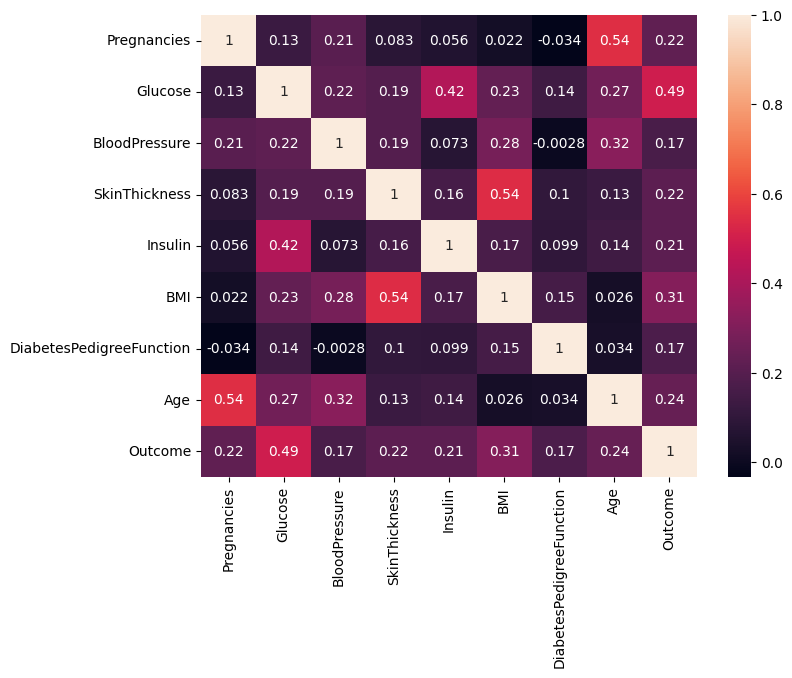

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()


## Feature Selection


In [24]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


# Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


## Training Model


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

# Prediction

In [27]:
y_pred = model.predict(X_test)


## Model Evaluation


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7467532467532467


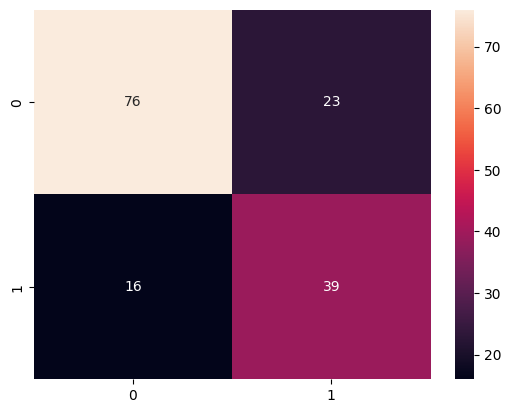

In [29]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()


## Feature Importance


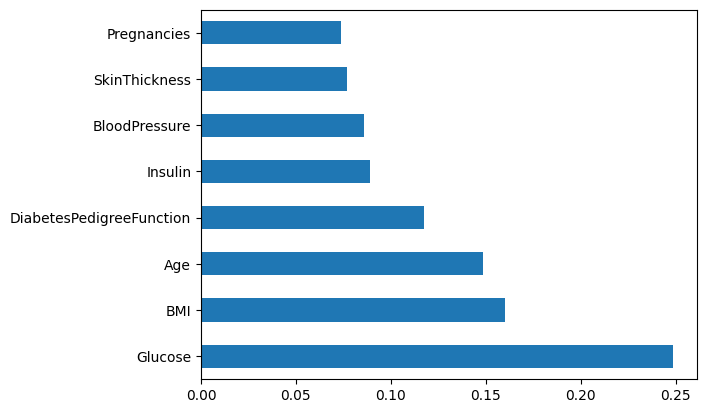

In [30]:
imp = pd.Series(model.feature_importances_,
                index=X.columns)

imp.nlargest(8).plot(kind='barh')
plt.show()


## Result

The model predicts diabetes risk with good accuracy.


## Conclusion

ML can help in early diabetes risk detection and awareness.


## Disclaimer

This model is for educational purposes and not medical diagnosis.
